In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import re
import seaborn as sns
from matplotlib.ticker import FuncFormatter

### Functions

In [2]:
def contains_only_digits(s):
    """
    Verifica si una cadena contiene únicamente dígitos utilizando expresiones regulares.
    
    Args:
    s (str): La cadena a evaluar.
    
    Returns:
    bool: True si la cadena contiene únicamente dígitos, False de lo contrario.
    """
    # Define el patrón de la expresión regular para buscar solo dígitos
    pattern = r'^\d+$'
    
    # Utiliza la función match() de la biblioteca re para buscar el patrón en la cadena
    # La función match() busca el patrón desde el principio de la cadena
    # Devuelve un objeto Match si el patrón coincide, None de lo contrario
    match = re.match(pattern, s)
    
    # Si match no es None, significa que el patrón coincide y la cadena contiene solo dígitos
    return match is not None

def abreviar_miles(x, pos):
    return '{:.0f}k'.format(x * 1e-3)
formatter = FuncFormatter(abreviar_miles)

def generate_graphs(df):
    fig, axes = plt.subplots(2, 4, figsize=(17, 8))
    for i, columna in enumerate(cols_hexagon_plot):
        row = i // 4
        col = i % 4
        ax = axes[row, col]
        hb = ax.hexbin(df['Likes'], df[columna], gridsize=35, bins='log', cmap='inferno')
        ax.set_title("Likes vs {}".format(columna))
        if columna != 'Care':
            ax.yaxis.set_major_formatter(formatter)
        ax.xaxis.set_major_formatter(formatter)
    cb = fig.colorbar(hb, ax=ax, label='counts')
    plt.tight_layout()
    plt.show()

### Load data

In [5]:
df = pd.read_pickle(r'..\..\..\data\preprocessed\stemm_lemm_text_nanook.pkl')

In [6]:
df.head(1)

,index,Facebook Id,Likes at Posting,Post Created,Type,Total Interactions,Likes,Comments,Shares,Love,...,Message,Image Text,Link Text,Description,score,messageChar_length,messageWords_length,Message_clean,Message_clean_stemm,Message_clean_lemm
0,0,153630631414604,NaN,2016-01-05 20:55:17 CST,Photo,"7,836",7266,442,63,51,...,A LOS NACIDOS ENTRE 1970 Y 1987 Somos una gene...,NaN,NaN,NaN,36.28,4329,720,a los nacidos entre 1970 y 1987 somos una gene...,a los nac entre 1970 y 1987 som una gener espe...,a el nacido entre 1970 y 1987 ser uno generaci...


In [7]:
df[['Likes','Comments', 'Shares', 'Love', 'Wow', 'Haha', 'Sad', 'Angry', 'Care']].describe()

,Likes,Comments,Shares,Love,Wow,Haha,Sad,Angry,Care
count,1.392634e+06,1.392634e+06,1.392634e+06,1.392634e+06,1.392634e+06,1.392634e+06,1.392634e+06,1.392634e+06,1.392634e+06
mean,5.205308e+01,6.522330e+00,3.286972e+01,5.855093e+00,3.775311e+00,3.661055e+00,6.686894e+00,2.080007e+00,2.863890e-01
std,8.178411e+02,7.943724e+01,1.082984e+03,2.515727e+02,1.295813e+02,9.334790e+01,1.721905e+02,6.174905e+01,1.684638e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.600000e+01,1.000000e+00,6.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,5.606940e+05,2.318300e+04,5.692520e+05,2.507780e+05,1.053630e+05,3.571000e+04,7.849000e+04,5.146400e+04,1.319700e+04


It seems that, **"Love", "Wow", "Haha", "Sad", "Angry", "Care"** does not have information only 25% of each interaction have data (NO ZERO).

- People does not use that button interactions!

# Total Interactions

- **¿?** `Total Interactions` = `Likes` + `Comments` + `Shares` + `Love` + `Wow` + `Haha` + `Sad` + `Angry` + `Care`

In [13]:
df.iloc[:,2:12].columns

Index(['Likes at Posting', 'Post Created', 'Type', 'Total Interactions',
       'Likes', 'Comments', 'Shares', 'Love', 'Wow', 'Haha'],
      dtype='object')

In [17]:
tot_inter_hipotesis = []
for i in df.iloc[:,2:12].iterrows():
    if i[1].values[0] is float:
        if contains_only_digits(i[1].values[0]):
            tot_int = int(i[1].values[0])
            sum_int = sum(i[1].values[1:])
            tot_inter_hipotesis.append(tot_int == sum_int)

In [18]:
all(tot_inter_hipotesis)

True

# Correlation between interactions

In [10]:
df.columns

Index(['index', 'Facebook Id', 'Likes at Posting', 'Post Created', 'Type',
       'Total Interactions', 'Likes', 'Comments', 'Shares', 'Love', 'Wow',
       'Haha', 'Sad', 'Angry', 'Care', 'Message', 'Image Text', 'Link Text',
       'Description', 'score', 'messageChar_length', 'messageWords_length',
       'Message_clean', 'Message_clean_stemm', 'Message_clean_lemm'],
      dtype='object')

In [11]:
corr_matrix = df[['Likes','Comments', 'Shares', 'Love', 'Wow', 'Haha', 'Sad', 'Angry', 'Care']].corr()

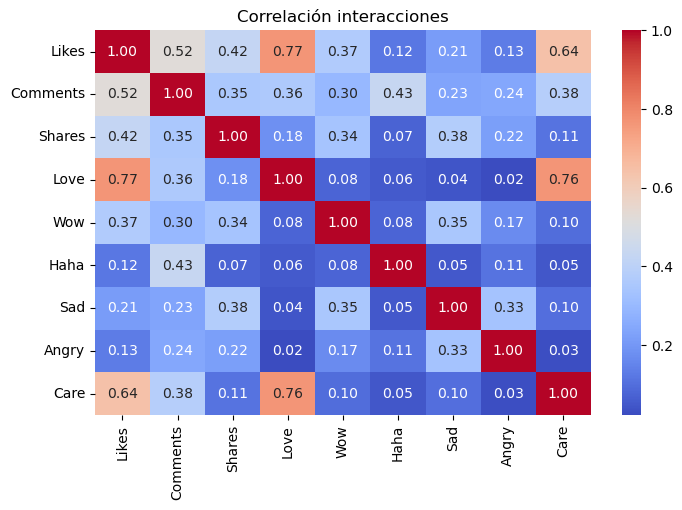

In [12]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación interacciones')
plt.show()

Seems that there is no correlation between variables, why?
- When does data was recopilated? When does interactions "Love", "Wow", "Haha", "Sad", "Angry", "Care" began?
- Does those interections are measure after they were created? I mean, are we measuring "Angry" when that option ever exists?

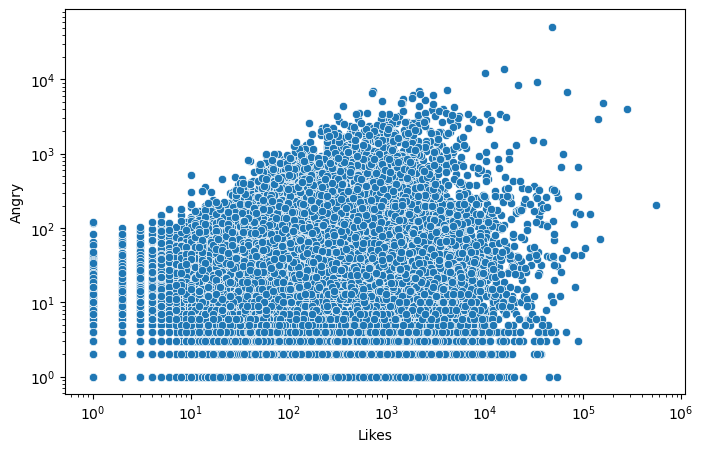

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Likes", y="Angry")
plt.yscale('log')
plt.xscale('log')
plt.show()

In [20]:
print(df['Likes'].min(), df['Likes'].max())
print(df['Angry'].min(), df['Angry'].max())

xlim = df['Likes'].min(), df['Likes'].max()
ylim = df['Angry'].min(), df['Angry'].max()

0 560694
0 51464


In [21]:
cols_hexagon_plot = ['Comments', 'Shares', 'Love', 'Wow', 'Haha', 'Sad', 'Angry', 'Care']

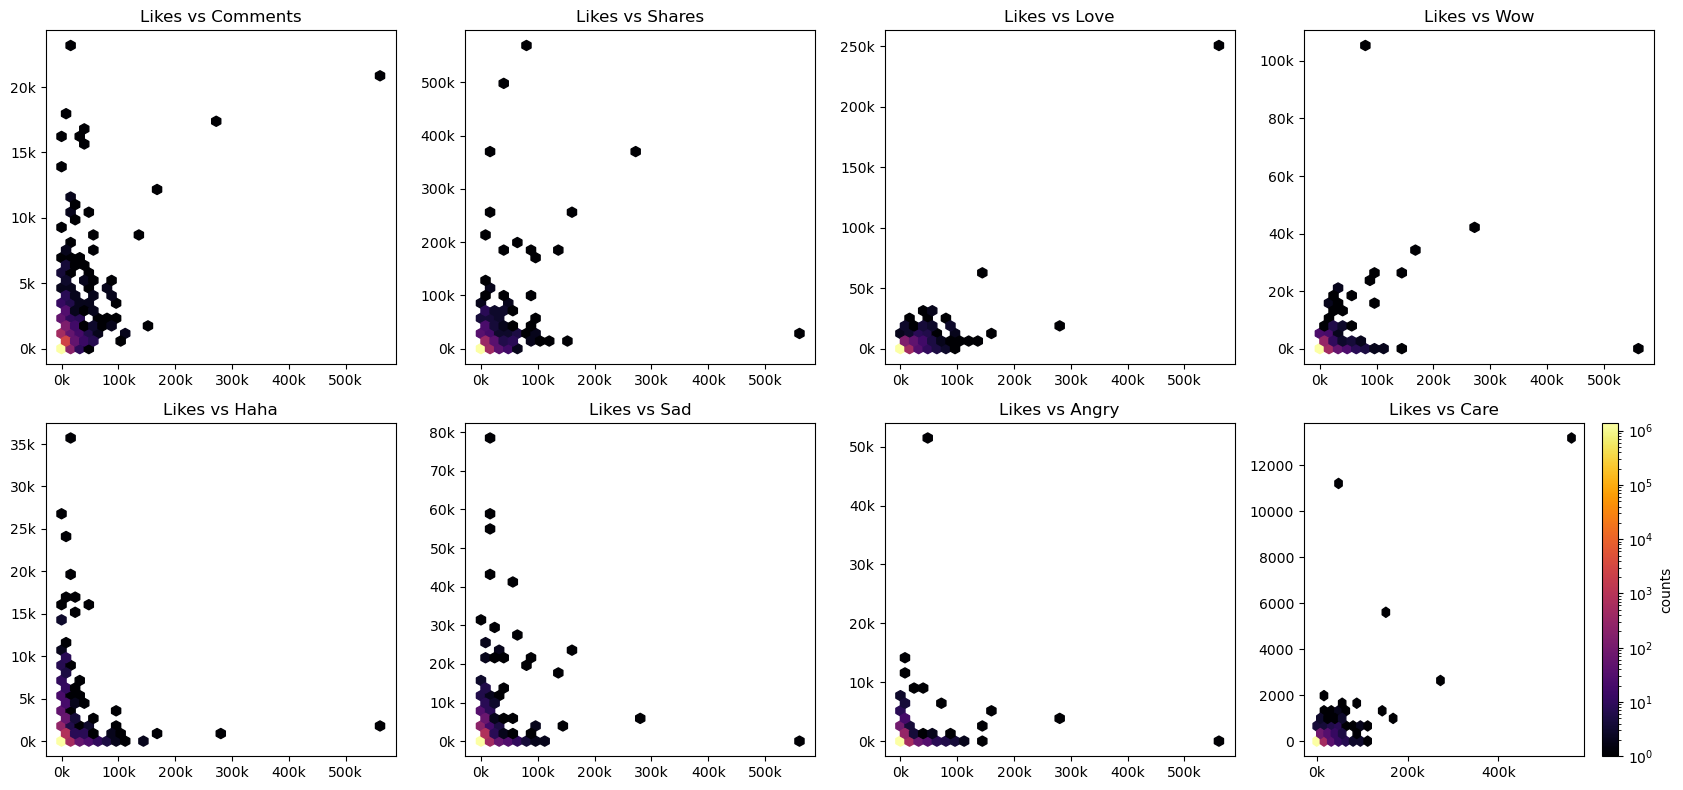

In [22]:
generate_graphs(df)

Due to, **"Love", "Wow", "Haha", "Sad", "Angry", "Care"** has minimum information I will analyze **"Likes"**

# Likes

In [23]:
cols_hist_plot = ['Likes', 'Comments', 'Shares', 'Love', 'Wow', 'Haha', 'Sad', 'Angry', 'Care']

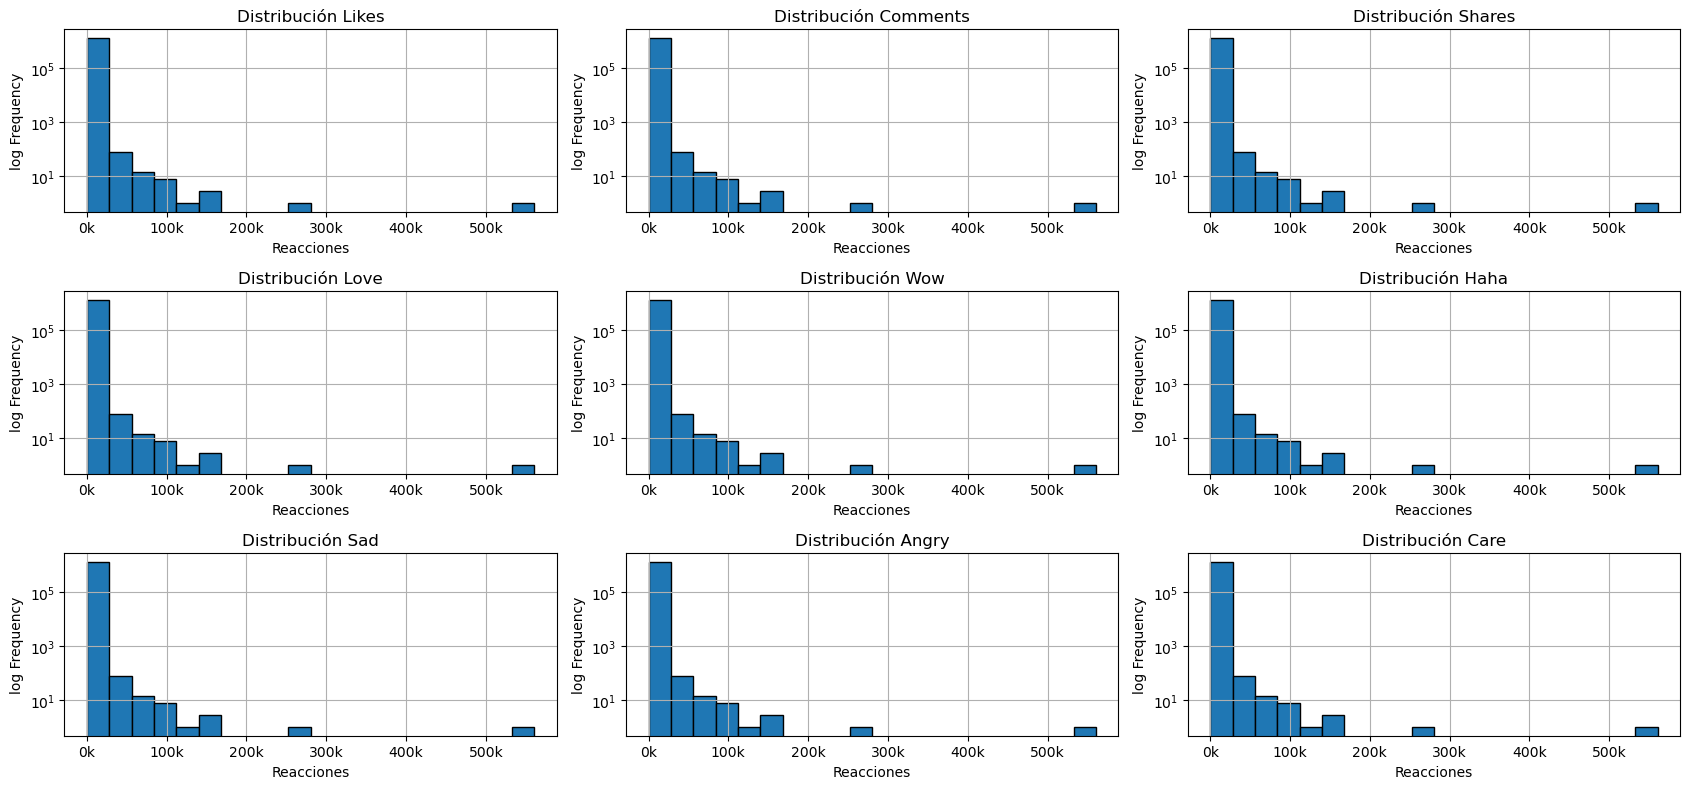

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(17, 8))
for i, columna in enumerate(cols_hist_plot):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    ax.xaxis.set_major_formatter(formatter)
    ax.hist(df["Likes"], bins=20, edgecolor='black')
    ax.set_title(f'Distribución {columna}')
    ax.set_xlabel("Reacciones")
    ax.set_ylabel('log Frequency')
    ax.set_yscale('log')
    ax.grid(True)
plt.tight_layout()
plt.show()